A parametric model of circumstellar disks 
---
See e.g. section 3.1 in https://ui.adsabs.harvard.edu/abs/2014ApJ...788...59W/abstract

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import xarray as xr
import os, sys
import matplotlib
from mpl_toolkits.axes_grid1 import make_axes_locatable
os.environ['CUDA_VISIBLE_DEVICES'] = '6'

sys.path.insert(0, '../')
import visualization, sensor, grid, line_rte
from network import shard
from consts import *

data_dir = '../../data/parametric'

## Define a parametric cylindrical model
---
The gas density and temparture are defined as azimuthally symetric
$$\rho(r,z),~~T(r,z)$$
where $r$ is the cylindrical coordinate radius 

In [2]:
def parametric_disk_temp(z, r, T_mid1, T_atm1, q, M_star, m_mol):
    # Temperature at the mid-plane is a power law with 2 parameters
    # Atmospheric tempertature is also a radial power law with 1 additional parameter
    # Typical values, T_mid1=200K, q=0.55, for Taurus protostars similar to those in the CO survey (Andrews et al. 2009)
    # Value range for T_atm1=500-1500K

    T_mid = T_mid1 * (r)**(-q)
    T_atm = T_atm1 * (r)**(-q)
    
    # The temperature profile is a combination of T_mid, T_atm 
    # delta, z_q describe the steepness of the profile and the hight at which 
    # the disk transitions to the atmopheric value. H_p is the pressure scale hight
    # derived from the midplane tempertaure
    

    H_p = (kk * T_mid * (r * au)**3 / (G*M_star*m_mol))**0.5
    delta, z_q = 2, 4*H_p/au
    temperature = np.where(np.abs(z)<z_q, T_mid + (T_atm - T_mid)*np.sin(np.pi*z/(2*z_q))**(2*delta), T_atm)
    return temperature

def parametric_disk_nd(z, r, temperature, gamma, r_in, r_c, M_gas, M_star, m_mol):
    sigma_0 = (2-gamma) * (M_gas / (2*np.pi*(r_c*au)**2)) * np.exp(r_in / r_c)**(2-gamma)
    sigma = sigma_0 * (r[0] / r_c)**(-gamma) * np.exp(-(r[0]/r_c)**(2-gamma))
    dz = np.diff(z * au, axis=0)
    dlogrho = ( au**(-2) * G*M_star*z/(r**2 + z**2)**(3/2) ) * (m_mol / (kk * temperature))
    dlogrho = -0.5*(dlogrho[:-1] + dlogrho[1:]) - np.log(temperature[1:]/temperature[:-1])/dz
    logrho = np.cumsum(dlogrho*dz, axis=0)
    logrho = np.pad(logrho, pad_width=[(1,0), (0,0)])
    rho = np.exp(logrho)
    rho = sigma * rho / (1+np.sum(rho[1:]*dz, axis=0, keepdims=True))
    numberdens = rho/m_mol
    return numberdens

In [3]:
# Parameters for the temperature and surface denisty profile chosen to match Fig 4 of https://iopscience.iop.org/article/10.1088/0004-637X/788/1/59/pdf
res = 500
z_min, z_max = 0, 200
r_min, r_max = 1, 300          # inner radius of the disk (au)
z, r = np.meshgrid(np.linspace(z_min, z_max, res), np.linspace(r_min, r_max, res), indexing='ij')
dz = np.diff(z * au, axis=0)[0,0]

# Define an azimuthally symmetric temperature profile (Kelvin)
T_mid1 = 200
T_atm1 = 1000
q = 0.55
M_star = 1.0 * M_sun
mu = 2.37       # mean molecular weight of the gas
m_mol = mu*m_h
temperature = parametric_disk_temp(z, r, T_mid1, T_atm1, q, M_star, m_mol)

# Define an azimuthally symmetric h2 number desnity profile (units of 1/cm^3)
# Compute the column integrated density N(h2) (units of 1/cm^2)
gamma = 0.75
r_in = 1
r_c = 60   
M_gas = 0.01 * M_sun
numberdens_h2 = parametric_disk_nd(z, r, temperature, gamma, r_in, r_c, M_gas, M_star, m_mol)
N_h2 = np.cumsum(numberdens_h2[::-1]*dz, axis=0)[::-1]

# CO chemestry, compute the relative abundance of co 
# Below T=20K there is CO depletion via freeze-out onto dust grains 
# At the upper layers of the disk, N_h2>N_dissoc, there is CO photodissociation due to radiation
N_dissoc = 1.3e21  # H_2 cm-2
abundance_co = np.where(np.bitwise_and(temperature>20, N_h2>N_dissoc), 1e-4, 0.0)
numberdens_co = abundance_co * numberdens_h2

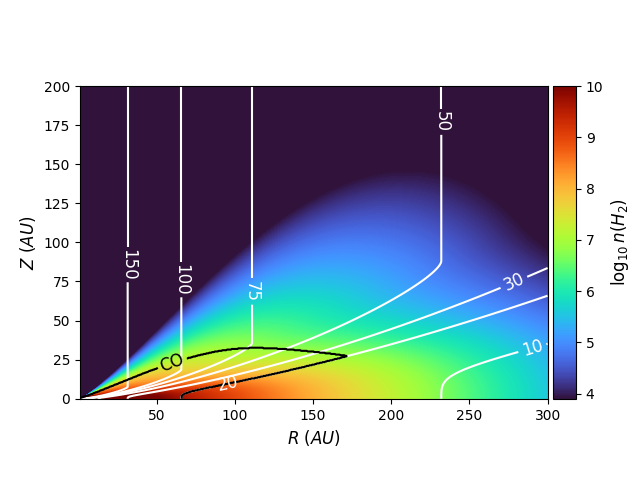

In [4]:
%matplotlib widget
fig, ax = plt.subplots()
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
im = ax.imshow(np.log10(numberdens_h2), origin='lower', cmap='turbo', extent=[r.min(),r.max(), z.min(), z.max()], vmin=3.9, vmax=10)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)
ax.set_xlabel(r'$R~(AU)$', fontsize=12)
ax.set_ylabel(r'$Z~(AU)$', fontsize=12)

levels = [10, 20, 30, 50, 75, 100, 150]
cp = ax.contour(r, z, temperature, levels, colors='white')
ax.clabel(cp, levels, inline=1, fontsize=12);
cp = ax.contour(r, z, abundance_co, levels=[5e-5], colors='black')
ax.clabel(cp, levels=[5e-5], fmt='CO', inline=1, fontsize=12);

# theta_max = np.deg2rad(68.5)
# ax.plot(np.sin(theta_max)*np.linspace(r_min, r_max), np.cos(theta_max)*np.linspace(r_min, r_max), color='r')

### Additional plots

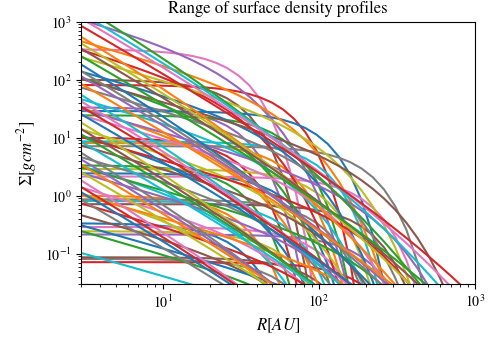

In [26]:
%matplotlib widget
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

r = np.logspace(np.log10(3), 4)
plt.figure(figsize=(5,3.5))
for gamma in [0.0, 0.75, 1.5]:
    for r_c in [30, 60, 100, 200]:
        for M_gas in np.array([1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1])*M_sun:
            sigma_0 = (2-gamma) * (M_gas / (2*np.pi*(r_c*au)**2)) * np.exp(1.0 / r_c)**(2-gamma)
            sigma = sigma_0 * (r / r_c)**(-gamma) * np.exp(-(r/r_c)**(2-gamma))
            plt.loglog(r, sigma);
            
plt.xlim(r[0],1e3);
plt.ylim(3e-2,1e3);
plt.ylabel(r'$\Sigma[g cm^{-2}]$', fontsize=12);
plt.xlabel(r'$R [AU]$', fontsize=12);
plt.tight_layout()
plt.title('Range of surface density profiles');

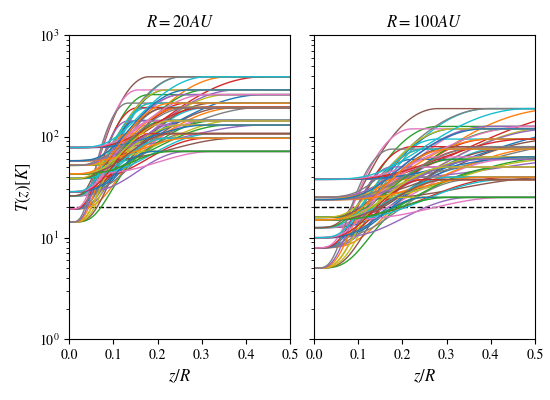

In [46]:
%matplotlib widget
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

fig, axes = plt.subplots(1,2, figsize=(5.5,4), sharey=True)
z_over_r = np.linspace(0, 0.5, 100)
for ax, r in zip(axes, [20, 100]):
    z = z_over_r * r
    ax.set_title(r'$R={}AU$'.format(r))
    ax.set_xlabel(r'$z/R$', fontsize=12);
    ax.set_xlim(0,0.5)
    ax.axhline(20, color='black', linestyle='--', linewidth=1)
    for M_star in [0.5*M_sun, 1.0*M_sun]:
        for T_mid1 in [100, 200, 300]:
            for T_atm1 in [500, 750, 1000, 1500]:
                for q in [0.45, 0.55, 0.65]:
                    T_mid = T_mid1 * (r)**(-q)
                    T_atm = T_atm1 * (r)**(-q)
                    
                    mu = 2.37      # mean molecular weight of the gas
                    H_p = (kk * T_mid * (r * au)**3 / (G*M_star*mu*m_h))**0.5
                    delta, z_q = 2, 4*H_p/au

                    temperature = np.where(np.abs(z)<z_q, T_mid + (T_atm - T_mid)*np.sin(np.pi*z/(2*z_q))**(2*delta), T_atm)
                    ax.semilogy(z_over_r, temperature, linewidth=1);
            
plt.ylim(1,1e3);
axes[0].set_ylabel(r'$T(z)[K]$', fontsize=12);
plt.tight_layout()

Render line radiative transfer cubes for CO 
---

In [5]:
# Make a spherical coordinate dataset with logarithmic spacing in r
phi, theta, r = np.meshgrid(
    np.linspace(0,2*np.pi, 180),
    np.deg2rad(np.linspace(68.5,111.5,120)), # np.deg2rad(np.linspace(65,115,120)),
    au * np.logspace(0, np.log10(200), 100),
    indexing='ij'
)
coords_sph = jnp.stack([phi, theta, r], axis=-1)

# Bounding box for interpolations (logarithmic r scale)
bbox = [(phi.min(), phi.max()), (theta.min(), theta.max()), (np.log10(r.min()), np.log10(r.max()))]

# Polar coordinates with mirror and axial symmetry
r_polar = r * np.sin(theta)
z = np.abs(r * np.cos(theta))
coords_polar = np.stack((z, r), axis=-1)

# Interpolate the data on spherical coordinates
numberdens_h2_sph = grid.interpolate_scalar(numberdens_h2, coords_polar, bbox=[(au*z_min, au*z_max), (au*r_min, au*r_max)])
numberdens_co_sph = grid.interpolate_scalar(numberdens_co, coords_polar, bbox=[(au*z_min, au*z_max), (au*r_min, au*r_max)])
temperature_sph = grid.interpolate_scalar(temperature, coords_polar, bbox=[(au*z_min, au*z_max), (au*r_min, au*r_max)])

In [86]:
# Sensor parameters
npix = 384
nray = 100
incl = 45.0
phi  = 100.0
posang = 0.0

fov = np.float32(1.1) * 2 * r.max()  # Note: float32 is to match radmc3d exact pixel grid
pixel_area = (fov/npix)**2       # pixel area to convert radiances to Jy 

ray_coords, obs_dir = sensor.orthographic_disk_projection(npix, nray, incl, phi, posang, fov, 20*au, 250*au, theta.min(), theta.max())
ray_coords_sph = grid.cartesian_to_spherical(ray_coords, logr=True)

# Interpolate dataset along the (spherical) ray coordinates
gas_nd = grid.interpolate_scalar(numberdens_co_sph, ray_coords_sph, bbox)
gas_t  = grid.interpolate_scalar(temperature_sph, ray_coords_sph, bbox, cval=1e-10)

# Einstein coefficient for spontaneous emission from level u to level d
energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=os.path.join(data_dir, 'molecule_12c16o.inp'))
nu0, a_ud, b_ud, b_du = line_rte.einstein_coefficients(energy_levels, radiative_transitions)
n_up, n_dn = line_rte.n_up_down(gas_nd, gas_t, energy_levels, radiative_transitions)
print('line frequency: {} Ghz'.format(nu0/ghz))

line frequency: 345.7959899 Ghz


In [87]:
# Compute line radiative transfer for a whole spectral cube
width_kms = 3.65
linenlam = 50
alpha_turb = 0.01 # km/s
camera_freqs = sensor.compute_camera_freqs(linenlam, width_kms, nu0)

# Keplerian velocity field
ray_x, ray_y, ray_z = ray_coords[...,0], ray_coords[...,1], ray_coords[...,2]
ray_r = np.sqrt(ray_x**2 + ray_y**2)
omega = np.sqrt(G * M_star / np.sqrt(ray_r**2 + ray_z**2))
cosp = ray_x/ray_r
sinp = ray_y/ray_r
vx, vy, vz = omega*cosp, omega*sinp, np.zeros_like(omega)
gas_v = np.stack([vx, vy, vz], axis=-1)

# Define a parallel mapping over several gpus
pmap = jax.pmap(line_rte.compute_spectral_cube,
                axis_name='freq', 
                in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None))

print('computing spectral cube for a total of {} frequencies'.format(camera_freqs.size))
images = pmap(shard(camera_freqs), gas_v, gas_t, n_up, n_dn, a_ud, b_ud, b_du, ray_coords, obs_dir, nu0, pixel_area, alpha_turb)
images = np.nan_to_num(images).reshape(linenlam, npix, npix)

computing spectral cube for a total of 50 frequencies


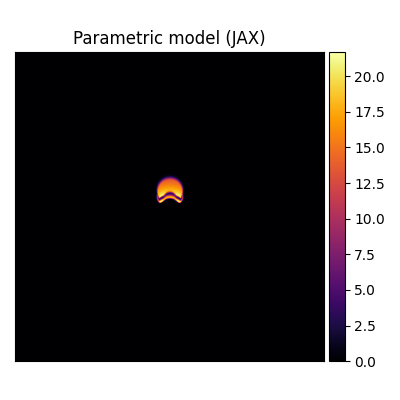

In [89]:
fig, axes = plt.subplots(1,1,figsize=(4,4))
output = 'gifs/parametric_model_jax.gif'
visualization.animate_movies_synced([images], [axes], fov=fov, vmin=[0.0]*3, cmaps='inferno', titles=['Parametric model (JAX)'], output=output)